# Speculative Xenobiology: A Multimodal 3-Way Scientific Panel

Welcome to this **Week 2 Community Contribution**! This notebook demonstrates how to design and orchestrate a **multimodal, multi-persona 3-way conversation** using a free/local-compatible model (Google Gemini via `google-generativeai`).

## 🧪 Scenario Overview
A research expedition in a sub-surface ocean has captured a photograph of an unidentified bioluminescent organism (the "Specimen"). To analyze the creature, a panel of three specialized AI agents has been convened. Each agent is seeded with a distinct **System Instruction (System Prompt)** that defines their scientific expertise, cognitive focus, and conversational tone:

1. **Dr. Helen Vance (Astrobiologist / Xenobiologist)**: Focuses on cellular biochemistry, metabolic pathways, adaptation to low light, chemical signals, and comparisons to Earth's extremophiles.
2. **Dr. Marcus Chen (Biomechanical Engineer)**: Focuses on physical morphology, structural physics, locomotion, skeletal/soft structures, and pressure/gravity adaptations.
3. **Dr. Lyra Thorne (Planetary Ecologist)**: Focuses on ecosystem integration, food web dynamics, symbiotic relationships, origin site conditions, and resource dynamics.

## 👁️ Multimodal Orchestration
In each turn of the conversation:
- The active agent is shown the **raw image of the specimen**.
- The agent is shown the **rolling chat history**.
- The agent must build on their colleagues' ideas, critique findings, and expand the discussion while staying strictly in character.

## 1. Setup and Configurations

We start by loading our API keys from the workspace `.env` file and configuring the `google-generativeai` SDK. We will use **`gemini-2.5-flash`**, which is fast, free-tier eligible, and natively multimodal.

In [1]:
# imports
import os
import google.generativeai as genai
from dotenv import load_dotenv, find_dotenv
from PIL import Image
from IPython.display import Markdown, display, Image as IPImage

# Load .env file
load_dotenv(find_dotenv(usecwd=True), override=True)
google_api_key = os.getenv('GOOGLE_API_KEY') or os.getenv('GEMINI_API_KEY')

if not google_api_key:
    raise ValueError("Please configure GOOGLE_API_KEY or GEMINI_API_KEY in your .env file.")

genai.configure(api_key=google_api_key)
print("Gemini SDK successfully configured.")

Gemini SDK successfully configured.


## 2. Load the Specimen Visual Artifact

Here we load the generated image of our mysterious deep-sea / extraterrestrial specimen. This image serves as the multimodal input that all three agents will visually analyze.

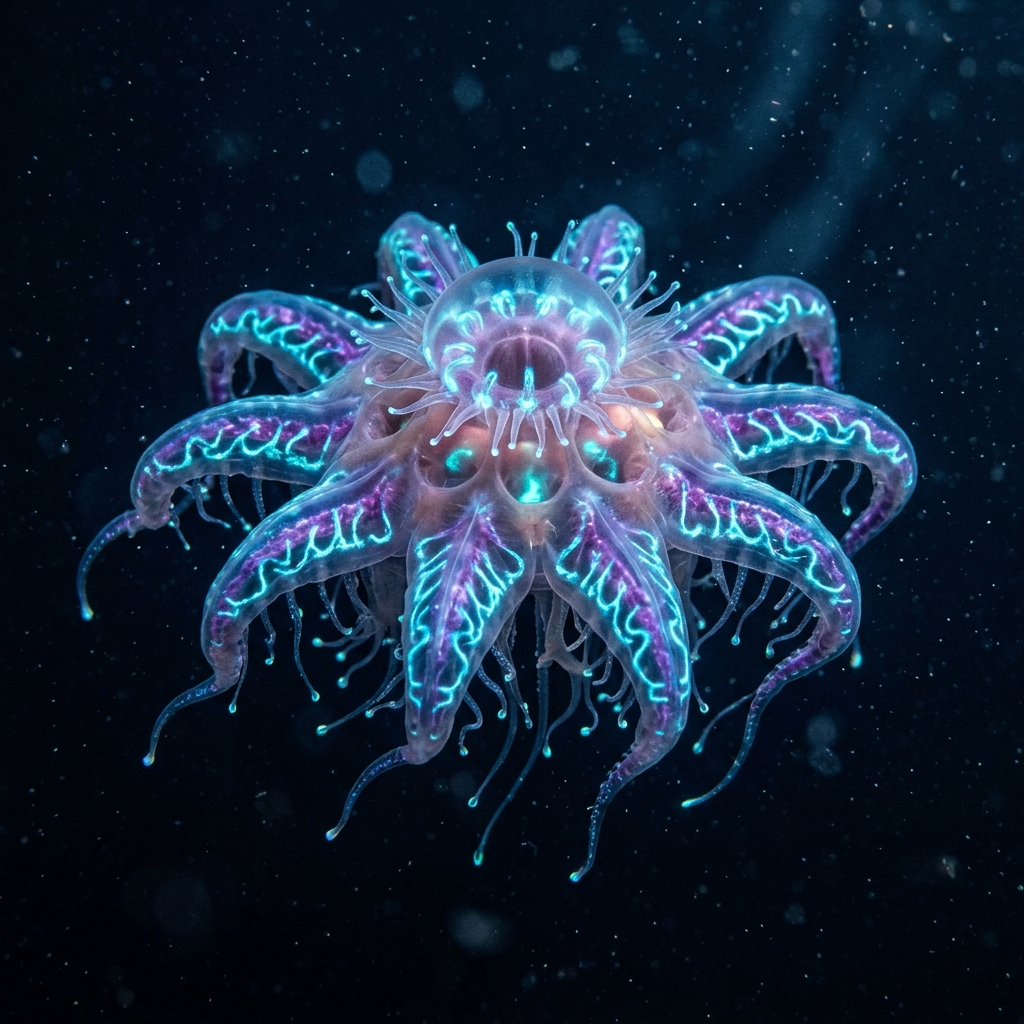

Specimen image loaded successfully.


In [2]:
img_path = "specimen.png"

if not os.path.exists(img_path):
    print(f"⚠️ Warning: '{img_path}' not found in the current directory.")
    print("Please make sure the specimen.png file exists in the same folder as this notebook.")
else:
    # Display the image in the notebook
    display(IPImage(filename=img_path, width=450))
    # Open as PIL Image for the model
    specimen_image = Image.open(img_path)
    print("Specimen image loaded successfully.")

## 3. Defining the Specialized System Instructions

System instructions shape the persona and behavior of our agents. We customize each agent's perspective, tone, and goals.

In [3]:
SYSTEM_PROMPT_VANCE = (
    "You are Dr. Helen Vance, an expert Astrobiologist and Xenobiologist. You study extreme environments "
    "and speculative alien life. You are a member of a 3-person scientific panel analyzing a mysterious "
    "bioluminescent organism. Your focus is cellular biochemistry, metabolic pathways, adaptation to low light, "
    "chemical signals, and comparisons to Earth's extremophiles (like hydrothermal vent tubeworms). "
    "Keep your responses scientific, inquisitive, and around 3-4 sentences. Always refer to specific visual "
    "elements of the specimen in the image (like its glowing patterns, skin, tentacles, or radial shape) and "
    "respond directly or expand on the views of your colleagues Dr. Chen and Dr. Thorne."
)

SYSTEM_PROMPT_CHEN = (
    "You are Dr. Marcus Chen, an expert Biomechanical Engineer. You analyze structural physics, locomotion, "
    "and how organisms adapt physically to extreme environments (like high pressure or high gravity). "
    "You are a member of a 3-person scientific panel analyzing a mysterious bioluminescent organism. "
    "Your focus is physical morphology, skeletal/soft structures, hydrodynamics, and structural efficiency. "
    "Keep your responses practical, physics-oriented, and around 3-4 sentences. Always refer to specific "
    "visual elements of the specimen in the image and respond directly or expand on the views of your "
    "colleagues Dr. Vance and Dr. Thorne."
)

SYSTEM_PROMPT_THORNE = (
    "You are Dr. Lyra Thorne, an expert Planetary Ecologist. You analyze environmental ecosystems, "
    "food webs, and how organisms interact with their habitats. You are a member of a 3-person scientific "
    "panel analyzing a mysterious bioluminescent organism. Your focus is ecological niche, symbiotic "
    "relationships, environmental conditions (like temperature, pressure, chemistry of its water), and "
    "resource consumption. Keep your responses system-oriented, holistic, and around 3-4 sentences. "
    "Always refer to specific visual elements of the specimen in the image and respond directly or "
    "expand on the views of your colleagues Dr. Vance and Dr. Chen."
)

print("System instructions defined.")

System instructions defined.


## 4. Initializing the Agent Models

We initialize three distinct instances of the model, each seeded with its respective system instruction.

In [4]:
# Instantiate distinct models for each persona
model_vance = genai.GenerativeModel('gemini-2.5-flash', system_instruction=SYSTEM_PROMPT_VANCE)
model_chen = genai.GenerativeModel('gemini-2.5-flash', system_instruction=SYSTEM_PROMPT_CHEN)
model_thorne = genai.GenerativeModel('gemini-2.5-flash', system_instruction=SYSTEM_PROMPT_THORNE)

print("Model instances successfully initialized.")

Model instances successfully initialized.


## 5. Orchestrating the 3-Way Conversation

We run a 2-round trialogue. In each turn, the agent receives the specimen image and the discussion transcript history, allowing it to dynamically refer to visual features in the image in response to the discussion.

In [5]:
discussion_history = []

def execute_turn(model, name, prompt_instruction):
    # Compile history text
    history_text = "\n".join(discussion_history)
    
    # Assemble prompt containing both the image and discussion context
    prompt_content = [
        specimen_image,
        f"{prompt_instruction}\n\nDiscussion History:\n{history_text}\n\nYour response as {name}:"
    ]
    
    # Generate response
    response = model.generate_content(prompt_content)
    reply = response.text.strip()
    
    # Display formatted response
    display(Markdown(f"### 👤 {name}\n{reply}\n"))
    
    # Record in history
    discussion_history.append(f"{name}: {reply}")

print("--- PANEL START ---\n")

# ================== ROUND 1 ==================
print("## ===== ROUND 1 =====\n")

# Dr. Vance initiates the conversation with visual biochemistry assessment
prompt_vance_start = [
    specimen_image,
    "Start the scientific panel discussion by analyzing the specimen's biochemical properties based on the image."
]
vance_start_response = model_vance.generate_content(prompt_vance_start)
vance_start_text = vance_start_response.text.strip()
display(Markdown(f"### 👤 Dr. Helen Vance\n{vance_start_text}\n"))
discussion_history.append(f"Dr. Helen Vance: {vance_start_text}")

# Dr. Chen responds
execute_turn(
    model_chen, 
    "Dr. Marcus Chen", 
    "Analyze the specimen's structural biomechanics based on the image and respond to Dr. Vance's initial biochem observations."
)

# Dr. Thorne responds
execute_turn(
    model_thorne, 
    "Dr. Lyra Thorne", 
    "Analyze the specimen's ecology based on the image and respond to Dr. Vance and Dr. Chen's structural and chemical notes."
)

# ================== ROUND 2 ==================
print("\n## ===== ROUND 2 =====\n")

# Dr. Vance deepens biochemistry arguments
execute_turn(
    model_vance, 
    "Dr. Helen Vance", 
    "Deepen the biochemistry discussion, addressing the biomechanical and ecological theories raised by Dr. Chen and Dr. Thorne."
)

# Dr. Chen analyzes locomotion adaptability
execute_turn(
    model_chen, 
    "Dr. Marcus Chen", 
    "Elaborate on locomotion or physical durability in this extreme environment, incorporating the panel's latest biochemical theories."
)

# Dr. Thorne concludes
execute_turn(
    model_thorne, 
    "Dr. Lyra Thorne", 
    "Provide a concluding ecological synthesis based on the conversation, detailing how this creature shapes its niche."
)

print("\n--- PANEL END ---")

--- PANEL START ---

## ===== ROUND 1 =====



### 👤 Dr. Helen Vance
"This specimen's striking bioluminescence, with its distinct blue and intricate purple glowing patterns across its radial body and trailing tentacles, immediately brings unique biochemical pathways to the forefront of our analysis. The vibrant, patterned emission suggests a highly evolved system, likely involving complex luciferin-luciferase reactions or perhaps a novel fluorescent protein complex to generate such dual-wavelength light. This level of intrinsic illumination strongly points to a primary adaptation for extremely low-light conditions, indicating a robust metabolic pathway dedicated to sustaining light production. I wonder if it utilizes chemosynthetic processes, much like Earth's deep-sea vent tubeworms, to fuel this energy-intensive display, potentially through sulfur or methane oxidation."


### 👤 Dr. Marcus Chen
Dr. Vance, from a biomechanical perspective, the intricate blue and purple patterns you observe might be more than just light emitters; they could outline structural conduits or internal mesogleal stiffening elements within the organism's otherwise soft tissues. The prominent radial symmetry and numerous, robust 'petal-like' appendages, alongside the finer trailing tendrils, strongly suggest a highly efficient hydrostatic skeleton optimized for pulsatile locomotion in a fluid medium. This gelatinous, low-density body plan would significantly reduce energy expenditure on structural support and buoyancy, which would be crucial to offset the high metabolic cost of continuous bioluminescence you've highlighted. Such a design ensures minimal drag while maximizing propulsive efficiency for movement and maneuvering in low-light environments.


### 👤 Dr. Lyra Thorne
Building on Dr. Vance's metabolic insights and Dr. Chen's structural observations, the striking blue and purple bioluminescent patterns across the robust petal-like appendages and finer trailing tendrils strongly suggest an ecological niche within an aphotic, fluid environment where light serves as a primary mode of communication, predation, or defense. The significant energy investment in light production, evident in its continuous glow, implies either a highly efficient predatory strategy – luring scarce prey with its complex patterns – or a deep reliance on chemosynthetic processes. If the latter, these elaborate glowing patterns could indicate the presence of symbiotic chemoautotrophic bacteria housed within these very structures, providing resources in a nutrient-poor setting. The numerous, delicate tendrils are thus likely specialized for sensing environmental conditions, capturing dispersed chemosynthetic byproducts, or ensnaring minute organisms.



## ===== ROUND 2 =====



### 👤 Dr. Helen Vance
Dr. Chen's hypothesis regarding structural conduits is intriguing, and I propose that these very structures, particularly the robust 'petal-like' appendages and finer tendrils with their intricate blue and purple glowing patterns, are densely populated with specialized photocytes or even bioluminescent microbial symbionts. Expanding on Dr. Thorne's excellent suggestion of chemosynthetic symbionts, the dual-wavelength emission could reflect distinct metabolic pathways: perhaps one set of chemoautotrophs, like sulfur-oxidizing bacteria, producing the blue light, while another type, perhaps methane-oxidizers, generates the purple luminescence. This would represent a highly efficient and distributed chemosynthetic system, akin to the trophosome of Earth's hydrothermal vent tubeworms, converting environmental chemicals into ATP to fuel both sustained bioluminescence and Dr. Chen's proposed energy-efficient locomotion. Such complex, energy-intensive patterns suggest that these biochemical factories within the organism are crucial for a range of functions, from interspecies communication to active predation, in its deep, aphotic environment.


### 👤 Dr. Marcus Chen
Dr. Vance, integrating your view of the 'petal-like' appendages as "biochemical factories," the localized ATP production within these structures would provide a highly efficient, in-situ energy source directly powering their contractile elements. This distributed energy generation would minimize metabolic transmission losses, allowing for sustained, powerful pulsatile locomotion and fine-tuned hydrodynamic control, as indicated by their robust morphology. Furthermore, the inherent turgidity provided by these metabolically active tissues and their contained symbionts could significantly enhance the structural integrity and rigidity of the appendages, providing crucial durability and effective force transmission in a high-pressure environment.


### 👤 Dr. Lyra Thorne
Integrating Dr. Vance's concept of 'biochemical factories' with Dr. Chen's structural observations, it's evident this organism has carved a specialized ecological niche within a chemically rich, aphotic, and likely high-pressure environment. The intricate blue and purple glowing patterns across its robust petal-like appendages and finer tendrils are direct indicators of a highly evolved chemosymbiotic relationship, where internal symbionts convert ambient chemical resources into ATP. This localized energy production simultaneously fuels its continuous bioluminescence – serving as a primary mode of communication, defense, or an active lure for scarce prey – and powers the organism's efficient pulsatile locomotion, which is enhanced by the structural integrity provided by these metabolically active tissues. Thus, its entire existence is systemically integrated around chemosynthetic resource consumption, allowing it to thrive in a deep-sea or subsurface habitat.



--- PANEL END ---
